In [1]:
import networkx as nx
import jax
import jax.numpy as jnp

{0: Text(-0.07660918563902959, 0.1012872126744104, '0'),
 1: Text(0.2549094954336884, -0.37941247001697076, '1'),
 2: Text(0.025013717599115852, 0.32612470374875446, '2'),
 3: Text(0.06057310280255306, 0.23014375130569464, '3'),
 4: Text(0.20260605222187655, -0.05595892002007347, '4'),
 5: Text(0.03919269554057543, -0.10375191295336147, '5'),
 6: Text(-0.1765503274729068, 0.01961570277523606, '6'),
 7: Text(0.06860624570120442, -1.0, '7'),
 8: Text(0.040311183450551374, 0.39361461749804394, '8'),
 9: Text(-0.1366083134131391, 0.15407608479436358, '9'),
 10: Text(-0.8624842957779637, 0.08729728140962394, '10'),
 11: Text(0.07920596550206152, 0.5241524697349835, '11'),
 12: Text(-0.06062214847832594, -0.06964762442022712, '12'),
 13: Text(0.3460022062237087, -0.4600553633292648, '13'),
 14: Text(0.03607658024224935, 0.11959774911959377, '14'),
 15: Text(-0.06793795448434764, 0.3114813604337835, '15'),
 16: Text(0.14756131778939252, -0.26312286491728654, '16'),
 17: Text(0.054279515904514

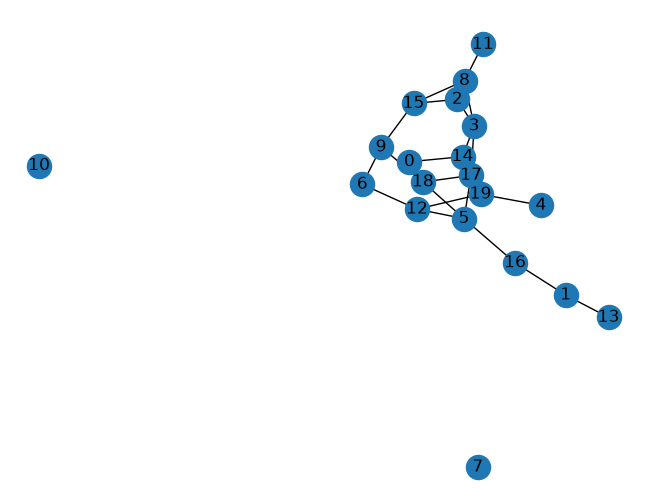

In [2]:
N = 20 #no. of nodes
p = 0.1 #ocu
G = nx.erdos_renyi_graph(N, p)
A = nx.to_numpy_array(G)
pos = nx.spring_layout(G)
labels = {node: str(node) for node in G.nodes()}
nx.draw(G, pos)
nx.draw_networkx_labels(G, pos, labels)

In [18]:
from bp_error.perc_func import perc_message_passing


connections = {}
node_weights = {}

for i in range(N):
    for j in range(N):
        if A[i][j] == 1 and A[j][i] == 1:
            connections[f'{i}, {j}'] = 0.5
            connections[f'{j}, {i}'] = 0.5

for i in range(0, 60):

    for key, values in connections.items():
        row, col = key.split(', ')
        failure = jnp.array([0, 0])
        failure = perc_message_passing(connections, A, int(row), int(col), 0.4, N)
        connections[f'{col}, {row}'] = float(failure[0]) #0.125 2->0
        connections[f'{row}, {col}'] = float(failure[1]) #0.5 0->2

for i in range(1, N):
    temp = 1
    for j in range(1, N):
        if A[i][j] == 1:
            temp = temp * connections[f'{i}, {j}']
    print (f'mu_i of {i}: {temp}')

mu_i of 1: 0.8585411906242371
mu_i of 2: 0.6568422483259617
mu_i of 3: 0.5213912910963558
mu_i of 4: 0.7613434195518494
mu_i of 5: 0.5075721263318528
mu_i of 6: 0.6576288009527573
mu_i of 7: 1
mu_i of 8: 0.6568422483259617
mu_i of 9: 0.5881096495685283
mu_i of 10: 1
mu_i of 11: 0.8138207197189331
mu_i of 12: 0.5667533949375254
mu_i of 13: 0.913821280002594
mu_i of 14: 0.6452467912692015
mu_i of 15: 0.6273218303811464
mu_i of 16: 0.752850353717804
mu_i of 17: 0.4455626564616582
mu_i of 18: 0.5396891830179718
mu_i of 19: 0.5297983882942973
